# Codificação de Sinais Multimedia

## Trabalho Laboratorial 2

- 52146 - Margarida Andrade
- 52345 - Jorge Gonçalves
- 52708 - Helena Nina

In [5]:
import numpy as np
import matplotlib.pyplot as plt

## Exercício A

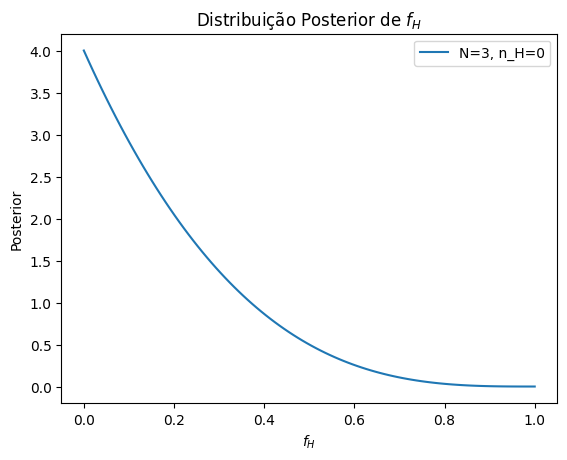

Probabilidade do próximo lançamento ser cara: 0.200


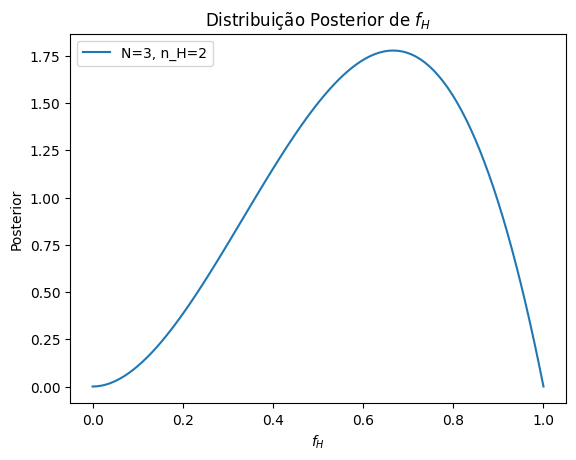

Probabilidade do próximo lançamento ser cara: 0.600


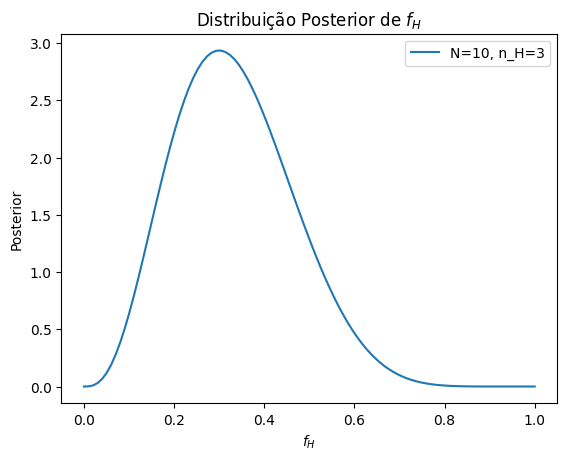

Probabilidade do próximo lançamento ser cara: 0.333


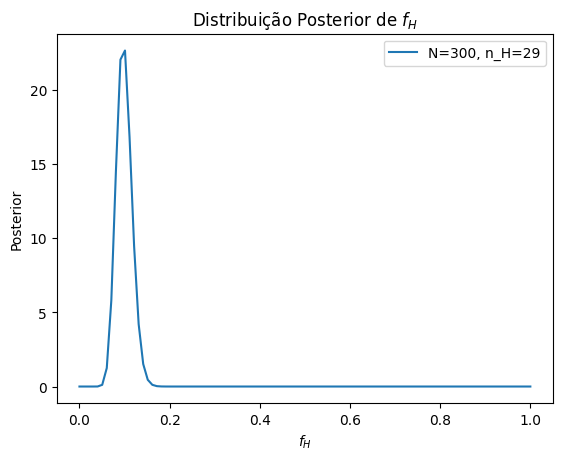

Probabilidade do próximo lançamento ser cara: 0.099


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

def plot_posterior(N, n_H):
    a = n_H + 1
    b = N - n_H + 1
    f_H = np.linspace(0, 1, 100)
    posterior = beta.pdf(f_H, a, b)
    plt.plot(f_H, posterior, label=f'N={N}, n_H={n_H}')
    plt.xlabel('$f_H$')
    plt.ylabel('Posterior')
    plt.title('Distribuição Posterior de $f_H$')
    plt.legend()
    plt.show()
    print(f'Probabilidade do próximo lançamento ser cara: {a/(a+b):.3f}')

# Exemplos do exercício
plot_posterior(3, 0)
plot_posterior(3, 2)
plot_posterior(10, 3)
plot_posterior(300, 29)

## Exercício B
### Alínea a.

In [4]:
# Prior dos algoritmos: [A, B, C]
P_algoritmo = np.array([0.40, 0.35, 0.25])

# Matriz de verosimilhança P(NC | algoritmo)
# Linhas: NC = 0,1,2,3,4 | Colunas: A,B,C
P_NC_dado_algoritmo = np.array([
    [0.05, 0.10, 0.20],
    [0.15, 0.20, 0.25],
    [0.40, 0.40, 0.30],
    [0.30, 0.20, 0.15],
    [0.10, 0.10, 0.10],
])

# Distribuição conjunta P(NC, algoritmo) = P(NC | algoritmo) * P(algoritmo)
P_conjunta = P_NC_dado_algoritmo * P_algoritmo

# Distribuição marginal dos níveis de compressão P(NC)
P_NC = P_conjunta.sum(axis=1)

# Validações dos axiomas/propriedades de probabilidade
assert np.allclose(np.sum(P_algoritmo), 1.0), 'O prior P(algoritmo) não soma 1.'
assert np.allclose(np.sum(P_NC_dado_algoritmo, axis=0), 1.0), 'Alguma coluna de P(NC|algoritmo) não soma 1.'
assert np.allclose(np.sum(P_conjunta), 1.0), 'A distribuição conjunta não soma 1.'
assert np.allclose(np.sum(P_NC), 1.0), 'A marginal P(NC) não soma 1.'

print('P_algoritmo =', P_algoritmo)
print('\nP(NC | algoritmo) =\n', P_NC_dado_algoritmo)
print('\nP_conjunta = P(NC, algoritmo) =\n', P_conjunta)
print('\nP(NC) (marginal) =', P_NC)
print('Soma de P(NC):', P_NC.sum())
print('\nValidação OK: todas as distribuições somam 1.')

P_algoritmo = [0.4  0.35 0.25]

P(NC | algoritmo) =
 [[0.05 0.1  0.2 ]
 [0.15 0.2  0.25]
 [0.4  0.4  0.3 ]
 [0.3  0.2  0.15]
 [0.1  0.1  0.1 ]]

P_conjunta = P(NC, algoritmo) =
 [[0.02   0.035  0.05  ]
 [0.06   0.07   0.0625]
 [0.16   0.14   0.075 ]
 [0.12   0.07   0.0375]
 [0.04   0.035  0.025 ]]

P(NC) (marginal) = [0.105  0.1925 0.375  0.2275 0.1   ]
Soma de P(NC): 1.0000000000000002

Validação OK: todas as distribuições somam 1.


### Alínea b.

In [5]:
def classifica_algoritmo(NC):
    """
    Devolve P(algoritmo | NC) para algoritmo em [A, B, C].
    """
    if NC < 0 or NC > 4:
        raise ValueError('NC deve estar entre 0 e 4.')

    numerador = P_NC_dado_algoritmo[NC, :] * P_algoritmo
    denominador = numerador.sum()
    posterior = numerador / denominador
    return posterior

# Classificação para NC observado = 3
NC_obs = 3
posterior_nc3 = classifica_algoritmo(NC_obs)
algoritmos = np.array(['A', 'B', 'C'])
algoritmo_MAP = algoritmos[np.argmax(posterior_nc3)]

print(f'P(algoritmo | NC={NC_obs}) =')
for alg, prob in zip(algoritmos, posterior_nc3):
    print(f'  {alg}: {prob:.6f}')

print(f'\nAlgoritmo mais provável (MAP): {algoritmo_MAP}')

P(algoritmo | NC=3) =
  A: 0.527473
  B: 0.307692
  C: 0.164835

Algoritmo mais provável (MAP): A


### Alínea c.

In [ ]:
# -------------------------
# Alínea c) ML e MAP
# -------------------------

niveis = np.arange(P_NC_dado_algoritmo.shape[0])  # [0,1,2,3,4]
algoritmos = np.array(['A', 'B', 'C'])

# ML: NC mais verosímil para cada algoritmo (argmax em P(NC|algoritmo), por coluna)
idx_ml_por_alg = np.argmax(P_NC_dado_algoritmo, axis=0)

print('ML - nível de compressão mais verosímil para cada algoritmo:')
for i, alg in enumerate(algoritmos):
    nc_ml = niveis[idx_ml_por_alg[i]]
    prob_ml = P_NC_dado_algoritmo[nc_ml, i]
    print(f'  Algoritmo {alg}: NC* = {nc_ml} (P={prob_ml:.3f})')

# MAP: algoritmo mais provável para cada NC observado (argmax em P(algoritmo|NC), por linha)
posterior_todos_nc = P_conjunta / P_NC[:, None]
idx_map_por_nc = np.argmax(posterior_todos_nc, axis=1)

print('\nMAP - algoritmo mais provável para cada nível observado NC:')
for nc in niveis:
    alg_map = algoritmos[idx_map_por_nc[nc]]
    probs = posterior_todos_nc[nc]
    print(f'  NC={nc}: algoritmo MAP = {alg_map} | P(A|NC)={probs[0]:.3f}, P(B|NC)={probs[1]:.3f}, P(C|NC)={probs[2]:.3f}')

ML - nível de compressão mais verosímil para cada algoritmo:
  Algoritmo A: NC* = 2 (P=0.400)
  Algoritmo B: NC* = 2 (P=0.400)
  Algoritmo C: NC* = 2 (P=0.300)

MAP - algoritmo mais provável para cada nível observado NC:
  NC=0: algoritmo MAP = C | P(A|NC)=0.190, P(B|NC)=0.333, P(C|NC)=0.476
  NC=1: algoritmo MAP = B | P(A|NC)=0.312, P(B|NC)=0.364, P(C|NC)=0.325
  NC=2: algoritmo MAP = A | P(A|NC)=0.427, P(B|NC)=0.373, P(C|NC)=0.200
  NC=3: algoritmo MAP = A | P(A|NC)=0.527, P(B|NC)=0.308, P(C|NC)=0.165
  NC=4: algoritmo MAP = A | P(A|NC)=0.400, P(B|NC)=0.350, P(C|NC)=0.250


### Alínea d.

In [ ]:
# -------------------------
# Alínea d) E[NC|algoritmo] e Var(NC|algoritmo)
# -------------------------

# E[NC|alg] = sum_nc nc * P(NC|alg)
media_nc_por_alg = np.sum(niveis[:, None] * P_NC_dado_algoritmo, axis=0)

# E[NC^2|alg]
seg_momento_por_alg = np.sum((niveis[:, None] ** 2) * P_NC_dado_algoritmo, axis=0)

# Var(NC|alg) = E[NC^2|alg] - (E[NC|alg])^2
var_nc_por_alg = seg_momento_por_alg - media_nc_por_alg**2

print('Valor esperado e variância do nível de compressão por algoritmo:')
for i, alg in enumerate(algoritmos):
    print(f'  {alg}: E[NC|{alg}] = {media_nc_por_alg[i]:.3f}, Var(NC|{alg}) = {var_nc_por_alg[i]:.3f}')

Valor esperado e variância do nível de compressão por algoritmo:
  A: E[NC|A] = 2.250, Var(NC|A) = 0.987
  B: E[NC|B] = 2.000, Var(NC|B) = 1.200
  C: E[NC|C] = 1.700, Var(NC|C) = 1.510


### Alínea e.

In [ ]:
# -------------------------
# Alínea e) Estimativa empírica com 50000 amostras
# -------------------------

N = 50000
np.random.seed(42)

# 1) Gerar algoritmos segundo o prior P(algoritmo)
alg_idx = np.random.choice(3, size=N, p=P_algoritmo)  # 0->A, 1->B, 2->C

# 2) Gerar NC segundo P(NC | algoritmo) para cada amostra
NC_sim = np.empty(N, dtype=int)
for i in range(3):
    mask = (alg_idx == i)
    n_i = np.sum(mask)
    if n_i > 0:
        NC_sim[mask] = np.random.choice(5, size=n_i, p=P_NC_dado_algoritmo[:, i])

# 3) Estimar empiricamente P(algoritmo | NC=2)
mask_nc2 = (NC_sim == 2)

if np.sum(mask_nc2) == 0:
    raise RuntimeError('Nenhuma amostra com NC=2. Aumente N ou mude a seed.')

contagens_emp = np.bincount(alg_idx[mask_nc2], minlength=3)
P_emp = contagens_emp / contagens_emp.sum()

# 4) Valor teórico: P(algoritmo | NC=2)
numerador_teo = P_NC_dado_algoritmo[2, :] * P_algoritmo
denominador_teo = np.sum(numerador_teo)
P_teo = numerador_teo / denominador_teo

# 5) Comparação
erro_abs = np.abs(P_emp - P_teo)

print(f'Total de amostras: {N}')
print(f'Amostras com NC=2: {contagens_emp.sum()}')
print('\nComparação P(algoritmo | NC=2):')
for i, alg in enumerate(algoritmos):
    print(
        f'  {alg}: empírico={P_emp[i]:.6f} | teórico={P_teo[i]:.6f} | erro abs={erro_abs[i]:.6f}'
    )

print(f'\nErro absoluto médio: {erro_abs.mean():.6f}')

Total de amostras: 50000
Amostras com NC=2: 18677

Comparação P(algoritmo | NC=2):
  A: empírico=0.427745 | teórico=0.426667 | erro abs=0.001079
  B: empírico=0.370081 | teórico=0.373333 | erro abs=0.003252
  C: empírico=0.202174 | teórico=0.200000 | erro abs=0.002174

Erro absoluto médio: 0.002168


## Exercício C
### Alínea a.
#### N = 4 e N = 10

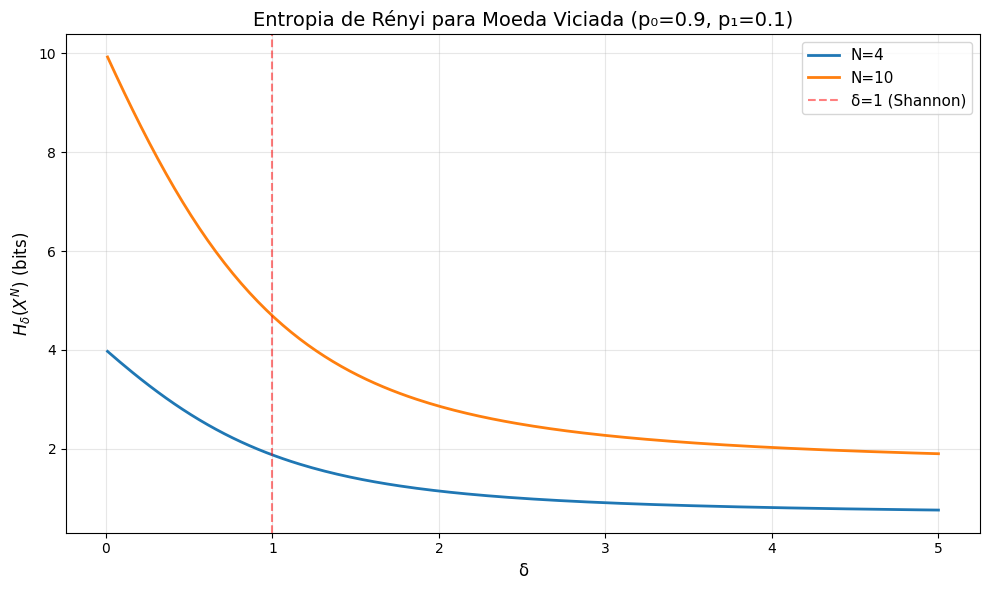

Valores de H_δ para N=4:
  δ=0.5: 2.6879 bits
  δ=1.0: 1.8912 bits (Shannon)
  δ=2.0: 1.1487 bits

Valores de H_δ para N=10:
  δ=0.5: 6.7197 bits
  δ=1.0: 4.7280 bits (Shannon)
  δ=2.0: 2.8717 bits


In [ ]:
# -------------------------
# Exercício C - Alínea a)
# Entropia de Rényi para moeda viciada
# -------------------------

def calcular_renyi_entropy(N, p0=0.9, p1=0.1):
    """
    Calcula a entropia de Rényi H_δ(X^N) para todas as sequências possíveis.
    
    Args:
        N: comprimento da sequência
        p0: probabilidade de cara (0)
        p1: probabilidade de coroa (1)
    
    Returns:
        delta_values: array de valores de δ
        H_delta: array de valores de H_δ
    """
    # Gerar todas as sequências possíveis
    num_sequences = 2 ** N
    
    # Calcular probabilidade de cada sequência
    probabilities = []
    for i in range(num_sequences):
        # Converter i em sequência binária de comprimento N
        seq = format(i, f'0{N}b')
        r_x = seq.count('1')  # número de coroas
        prob = (p0 ** (N - r_x)) * (p1 ** r_x)
        probabilities.append(prob)
    
    probabilities = np.array(probabilities)
    
    # Calcular H_δ para diferentes valores de δ
    delta_values = np.linspace(0.01, 5, 200)
    H_delta = []
    
    for delta in delta_values:
        if np.isclose(delta, 1.0):
            # H_1 = entropia de Shannon = -Σ p_i * log_2(p_i)
            H = -np.sum(probabilities[probabilities > 0] * np.log2(probabilities[probabilities > 0]))
        else:
            # H_δ = (1/(1-δ)) * log_2(Σ p_i^δ)
            sum_p_delta = np.sum(probabilities ** delta)
            H = (1 / (1 - delta)) * np.log2(sum_p_delta)
        
        H_delta.append(H)
    
    return delta_values, np.array(H_delta)

# Calcular para N=4 e N=10
delta_4, H_4 = calcular_renyi_entropy(4)
delta_10, H_10 = calcular_renyi_entropy(10)

# Plotar
plt.figure(figsize=(10, 6))
plt.plot(delta_4, H_4, label='N=4', linewidth=2)
plt.plot(delta_10, H_10, label='N=10', linewidth=2)
plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='δ=1 (Shannon)')
plt.xlabel('δ', fontsize=12)
plt.ylabel('$H_δ(X^N)$ (bits)', fontsize=12)
plt.title('Entropia de Rényi para Moeda Viciada (p₀=0.9, p₁=0.1)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar alguns valores importantes
print("Valores de H_δ para N=4:")
print(f"  δ=0.5: {H_4[np.argmin(np.abs(delta_4 - 0.5))]:.4f} bits")
print(f"  δ=1.0: {H_4[np.argmin(np.abs(delta_4 - 1.0))]:.4f} bits (Shannon)")
print(f"  δ=2.0: {H_4[np.argmin(np.abs(delta_4 - 2.0))]:.4f} bits")

print("\nValores de H_δ para N=10:")
print(f"  δ=0.5: {H_10[np.argmin(np.abs(delta_10 - 0.5))]:.4f} bits")
print(f"  δ=1.0: {H_10[np.argmin(np.abs(delta_10 - 1.0))]:.4f} bits (Shannon)")
print(f"  δ=2.0: {H_10[np.argmin(np.abs(delta_10 - 2.0))]:.4f} bits")

### Alínea b.
#### N = 10, 210, 410, 610, 810, 1010


A gerar amostras e a calcular entropias de Rényi...
Número de amostras por N: 1000

  N = 10... OK
  N = 210... OK
  N = 410... OK
  N = 610... OK
  N = 810... OK
  N = 1010... OK

Cálculo concluído!



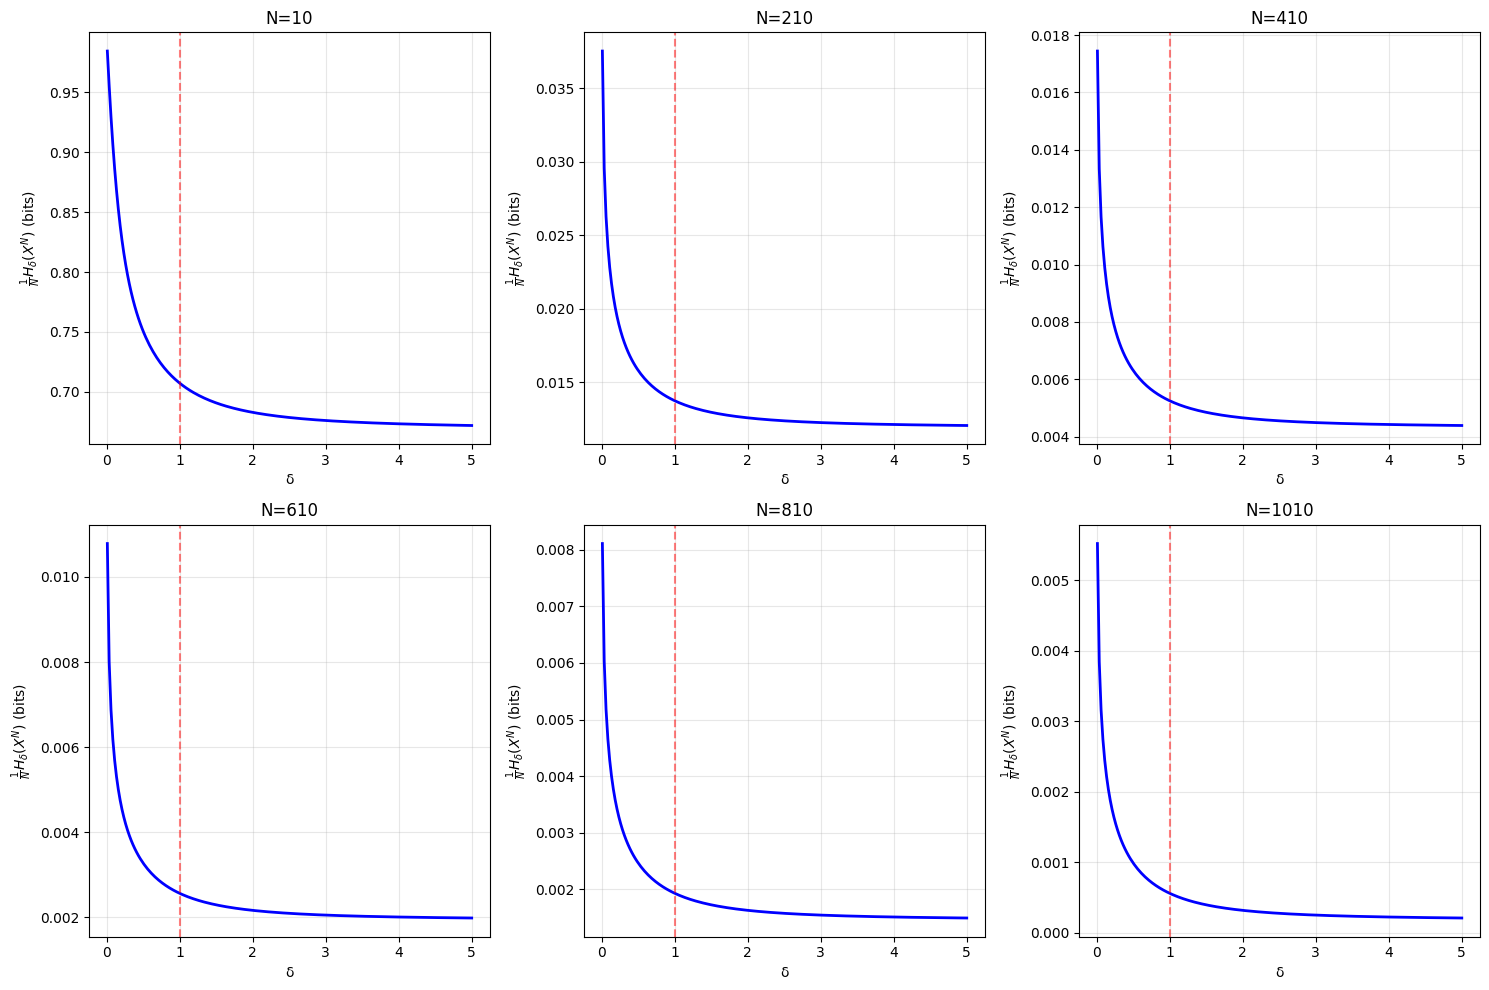

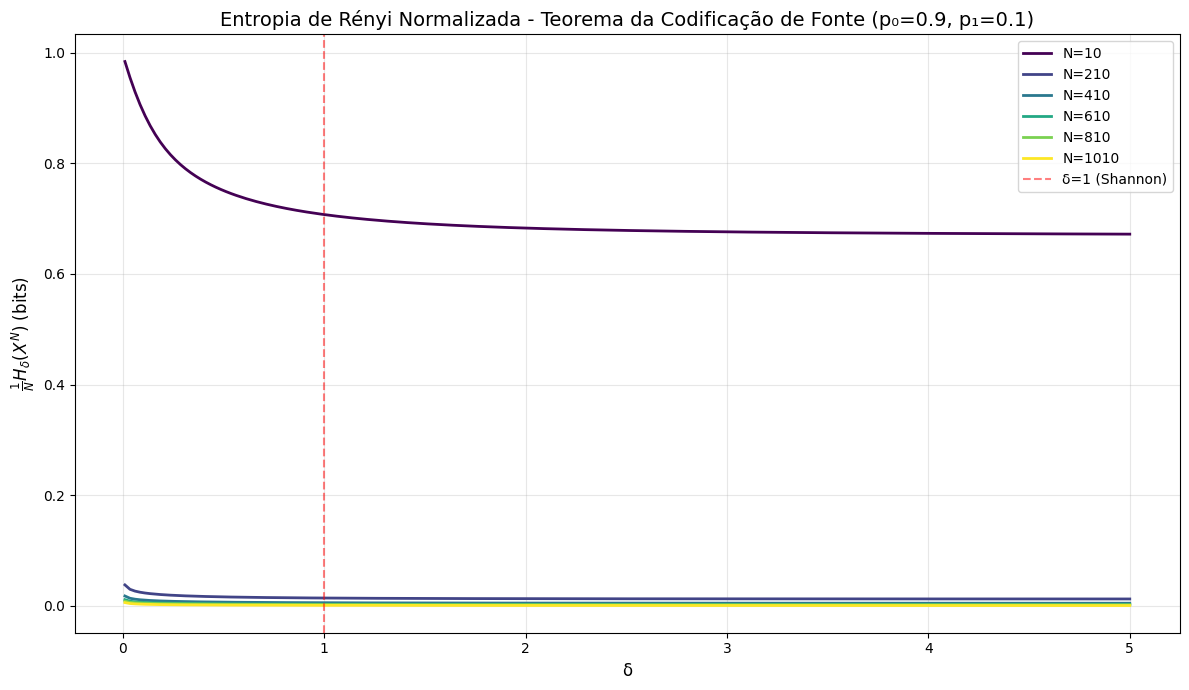

Resumo de Valores de 1/N * H_δ (para δ=0.5, 1.0, 2.0):

N        δ=0.5 (bits)    δ=1.0 (bits)    δ=2.0 (bits)   
--------------------------------------------------
10       0.7491          0.7080          0.6831         
210      0.0157          0.0138          0.0126         
410      0.0063          0.0053          0.0047         
610      0.0033          0.0026          0.0022         
810      0.0024          0.0019          0.0016         
1010     0.0010          0.0006          0.0003         

Observação: Os valores devem convergir para a entropia de Shannon (δ=1.0)
quando N aumenta, verificando o Teorema da Codificação de Fonte.


In [10]:
# -------------------------
# Exercício C - Alínea b)
# Entropia de Rényi usando amostragem (Teorema da Codificação de Fonte de Shannon)
# 1/N * H_δ(X^N) em função de δ
# -------------------------

from scipy.special import comb

def gerar_amostras_balanceadas(N, num_amostras=1000, seed=42):
    """
    Gera 1000 amostras de sequências binárias de comprimento N,
    com número de 1s distribuído uniformemente de 0 a N.
    
    Args:
        N: comprimento da sequência
        num_amostras: número total de amostras (default 1000)
        seed: seed para reprodutibilidade
    
    Returns:
        amostras: array (num_amostras, N) com sequências binárias
    """
    np.random.seed(seed)
    
    amostras = np.zeros((num_amostras, N), dtype=int)
    
    # Distribuir as amostras uniformemente pelos possíveis números de 1s (0 a N)
    num_classes = N + 1  # números de 1s: 0, 1, 2, ..., N
    amostras_por_classe = num_amostras // num_classes
    resto = num_amostras % num_classes
    
    indice = 0
    for num_ones in range(num_classes):
        # Alguns números de 1s podem ter uma amostra extra
        n_desta_classe = amostras_por_classe + (1 if num_ones < resto else 0)
        
        # Gerar amostras com exatamente 'num_ones' 1s
        for j in range(n_desta_classe):
            posicoes = np.random.choice(N, size=num_ones, replace=False)
            amostras[indice, posicoes] = 1
            indice += 1
    
    return amostras

def calcular_renyi_entropy_amostras(amostras, p0=0.9, p1=0.1):
    """
    Calcula a entropia de Rényi H_δ a partir de amostras.
    
    Args:
        amostras: array (num_amostras, N) com sequências binárias
        p0: probabilidade de 0 (cara)
        p1: probabilidade de 1 (coroa)
    
    Returns:
        delta_values: array de valores de δ
        H_delta: array de valores de H_δ
    """
    num_amostras, N = amostras.shape
    
    # Calcular probabilidade de cada amostra
    # P(x) = p0^(número de 0s) * p1^(número de 1s)
    num_ones = np.sum(amostras, axis=1)  # número de 1s em cada amostra
    num_zeros = N - num_ones
    
    log_probs = num_zeros * np.log(p0) + num_ones * np.log(p1)
    
    # Normalizar
    from scipy.special import logsumexp
    log_probs_norm = log_probs - logsumexp(log_probs)
    probs = np.exp(log_probs_norm)
    
    # Calcular H_δ para diferentes valores de δ
    delta_values = np.linspace(0.01, 5, 200)
    H_delta = []
    
    for delta in delta_values:
        if np.isclose(delta, 1.0):
            # H_1 = entropia de Shannon
            mask = probs > 1e-300
            H = -np.sum(probs[mask] * np.log2(probs[mask]))
        else:
            # H_δ = (1/(1-δ)) * log_2(Σ p_i^δ)
            sum_p_delta = np.sum(probs ** delta)
            H = (1 / (1 - delta)) * np.log2(sum_p_delta)
        
        H_delta.append(H)
    
    return delta_values, np.array(H_delta)

# Valores de N a estudar
N_values = [10, 210, 410, 610, 810, 1010]
num_amostras = 1000

# Calcular H_δ para cada N
print("A gerar amostras e a calcular entropias de Rényi...")
print(f"Número de amostras por N: {num_amostras}\n")

results = {}
for N in N_values:
    print(f"  N = {N}...", end=' ', flush=True)
    amostras = gerar_amostras_balanceadas(N, num_amostras=num_amostras)
    delta, H = calcular_renyi_entropy_amostras(amostras)
    results[N] = (delta, H / N)  # Normalizar por N: 1/N * H_δ(X^N)
    print("OK")

print("\nCálculo concluído!\n")

# Plotar 1/N * H_δ em função de δ - em 6 subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, N in enumerate(N_values):
    delta, H_norm = results[N]
    axes[idx].plot(delta, H_norm, linewidth=2, color='blue')
    axes[idx].axvline(x=1.0, color='red', linestyle='--', alpha=0.5)
    axes[idx].set_xlabel('δ', fontsize=10)
    axes[idx].set_ylabel('$\\frac{1}{N}H_δ(X^N)$ (bits)', fontsize=10)
    axes[idx].set_title(f'N={N}', fontsize=12)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparação em um único gráfico
plt.figure(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0, 1, len(N_values)))

for idx, N in enumerate(N_values):
    delta, H_norm = results[N]
    plt.plot(delta, H_norm, label=f'N={N}', linewidth=2, color=colors[idx])

plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='δ=1 (Shannon)')
plt.xlabel('δ', fontsize=12)
plt.ylabel('$\\frac{1}{N}H_δ(X^N)$ (bits)', fontsize=12)
plt.title('Entropia de Rényi Normalizada - Teorema da Codificação de Fonte (p₀=0.9, p₁=0.1)', fontsize=14)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar valores importantes para cada N
print("Resumo de Valores de 1/N * H_δ (para δ=0.5, 1.0, 2.0):\n")
print(f"{'N':<8} {'δ=0.5 (bits)':<15} {'δ=1.0 (bits)':<15} {'δ=2.0 (bits)':<15}")
print("-" * 50)

for N in N_values:
    delta, H_norm = results[N]
    h_05 = H_norm[np.argmin(np.abs(delta - 0.5))]
    h_10 = H_norm[np.argmin(np.abs(delta - 1.0))]
    h_20 = H_norm[np.argmin(np.abs(delta - 2.0))]
    print(f"{N:<8} {h_05:<15.4f} {h_10:<15.4f} {h_20:<15.4f}")

print("\n" + "="*50)
print("Observação: Os valores devem convergir para a entropia de Shannon (δ=1.0)")
print("quando N aumenta, verificando o Teorema da Codificação de Fonte.")
print("="*50)